# Heart Disease Modeling in Colab

This notebook trains and evaluates baseline models using the train-test split artifacts.

What this notebook does:
- Upload and extract artifacts zip
- Load train and test CSV files
- Build preprocessing + model pipelines
- Train Logistic Regression and Random Forest
- Evaluate with Accuracy, Precision, Recall, F1, ROC-AUC
- Show confusion matrices and ROC curves
- Export predictions and metrics for sharing

In [1]:
!pip -q install pandas numpy scikit-learn seaborn matplotlib

In [2]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

OUTPUT_DIR = Path("model_artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")

Setup complete


## 1. Upload artifacts zip from EDA notebook
Upload `heart_eda_artifacts.zip` that was downloaded from the first notebook.

In [4]:
from google.colab import files

uploaded = files.upload()
if len(uploaded) == 0:
    raise ValueError("No file uploaded. Upload heart_eda_artifacts.zip")

zip_name = list(uploaded.keys())[0]
if not zip_name.lower().endswith(".zip"):
    raise ValueError("Please upload a .zip file (heart_eda_artifacts.zip)")

with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall(".")

print(f"Extracted: {zip_name}")

Saving artifacts.zip to artifacts.zip
Extracted: artifacts.zip


In [5]:
split_dir = Path("artifacts") / "train_test_split"

required_files = [
    split_dir / "X_train.csv",
    split_dir / "X_test.csv",
    split_dir / "y_train.csv",
    split_dir / "y_test.csv",
]

missing = [str(f) for f in required_files if not f.exists()]
if missing:
    raise FileNotFoundError(f"Missing split files: {missing}")

X_train = pd.read_csv(split_dir / "X_train.csv")
X_test = pd.read_csv(split_dir / "X_test.csv")
y_train = pd.read_csv(split_dir / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(split_dir / "y_test.csv").squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)


## 2. Build preprocessing pipeline

In [6]:
categorical_cols = []
numerical_cols = []

for c in X_train.columns:
    if pd.api.types.is_object_dtype(X_train[c]) or pd.api.types.is_bool_dtype(X_train[c]):
        categorical_cols.append(c)
    elif pd.api.types.is_integer_dtype(X_train[c]) and X_train[c].nunique(dropna=True) <= 10:
        categorical_cols.append(c)
    else:
        numerical_cols.append(c)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

## 3. Train baseline models

In [7]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=300, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
}

trained = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    acc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")

    cv_rows.append({
        "model": name,
        "cv_auc_mean": round(float(np.mean(auc_scores)), 4),
        "cv_auc_std": round(float(np.std(auc_scores)), 4),
        "cv_acc_mean": round(float(np.mean(acc_scores)), 4),
        "cv_acc_std": round(float(np.std(acc_scores)), 4),
    })

    pipe.fit(X_train, y_train)
    trained[name] = pipe

cv_results = pd.DataFrame(cv_rows).sort_values("cv_auc_mean", ascending=False)
display(cv_results)
cv_results.to_csv(OUTPUT_DIR / "cv_results.csv", index=False)

,model,cv_auc_mean,cv_auc_std,cv_acc_mean,cv_acc_std
0,LogisticRegression,0.8904,0.0355,0.8182,0.0562
1,RandomForest,0.8860,0.0592,0.8056,0.0787


## 4. Evaluate on test set


LogisticRegression classification report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        28
           1       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



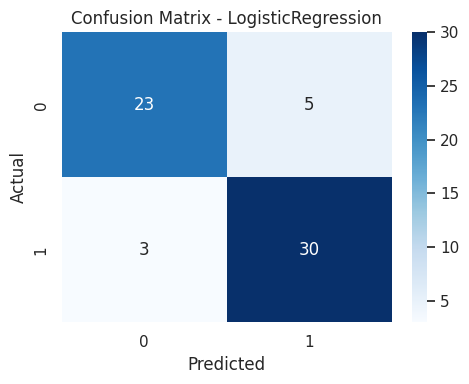


RandomForest classification report:
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



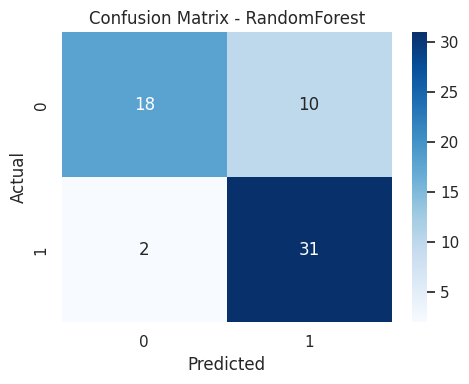

,model,accuracy,precision,recall,f1,roc_auc
1,RandomForest,0.8033,0.7561,0.9394,0.8378,0.9150
0,LogisticRegression,0.8689,0.8571,0.9091,0.8824,0.9102


In [8]:
def evaluate_model(name, estimator, X_test, y_test):
    y_pred = estimator.predict(X_test)

    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_test)[:, 1]
    else:
        y_score = estimator.decision_function(X_test)

    metrics = {
        "model": name,
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "precision": round(float(precision_score(y_test, y_pred)), 4),
        "recall": round(float(recall_score(y_test, y_pred)), 4),
        "f1": round(float(f1_score(y_test, y_pred)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, y_score)), 4),
    }

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_score)

    pred_df = pd.DataFrame({
        "y_true": y_test.values,
        "y_pred": y_pred,
        "y_score": y_score
    })

    return metrics, cm, fpr, tpr, pred_df

all_metrics = []
all_rocs = {}

for name, est in trained.items():
    metrics, cm, fpr, tpr, pred_df = evaluate_model(name, est, X_test, y_test)
    all_metrics.append(metrics)
    all_rocs[name] = (fpr, tpr)

    print(f"\n{name} classification report:")
    print(classification_report(y_test, pred_df["y_pred"]))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

    pred_df.to_csv(OUTPUT_DIR / f"predictions_{name}.csv", index=False)

metrics_df = pd.DataFrame(all_metrics).sort_values("roc_auc", ascending=False)
display(metrics_df)
metrics_df.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)

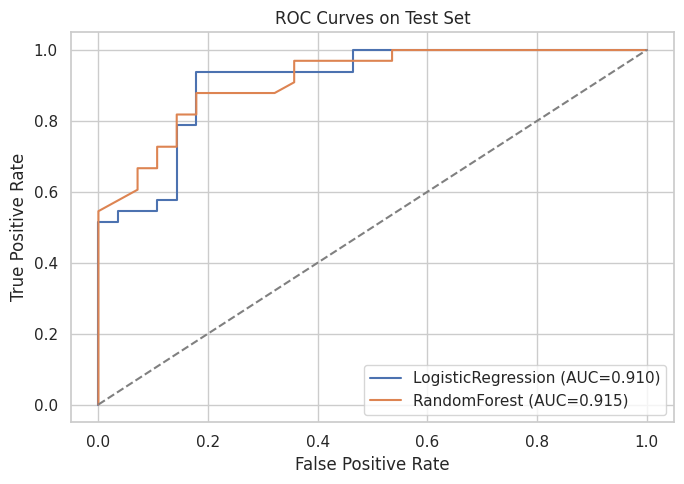

In [9]:
plt.figure(figsize=(7, 5))
for name, (fpr, tpr) in all_rocs.items():
    auc_val = metrics_df.loc[metrics_df["model"] == name, "roc_auc"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=150)
plt.show()

## 5. Export final bundle

In [10]:
summary_lines = []
summary_lines.append("# Modeling Summary")
summary_lines.append("")
summary_lines.append("## Cross-validation")
summary_lines.append(cv_results.to_markdown(index=False))
summary_lines.append("")
summary_lines.append("## Test Metrics")
summary_lines.append(metrics_df.to_markdown(index=False))

summary_path = OUTPUT_DIR / "MODEL_REPORT.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

bundle_path = Path("heart_modeling_artifacts.zip")
with zipfile.ZipFile(bundle_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.as_posix())

print(f"Created: {bundle_path}")
display(metrics_df)

from google.colab import files
files.download(str(bundle_path))

Created: heart_modeling_artifacts.zip


,model,accuracy,precision,recall,f1,roc_auc
1,RandomForest,0.8033,0.7561,0.9394,0.8378,0.9150
0,LogisticRegression,0.8689,0.8571,0.9091,0.8824,0.9102


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>